# Feature transformation, scaling, and encoding


# Feature Transformation
-> It changes the shape or distribution of data. 

# Log Transformation
-> It is used when data is right-skewed.

- formula: log(x+1)


In [1]:
import numpy as np
import pandas as pd

x = pd.Series([1, 10, 100, 1000])
x_log = np.log1p(x)
print (x_log)

0    0.693147
1    2.397895
2    4.615121
3    6.908755
dtype: float64


In [ ]:
# without using any functions
import math
x = pd.Series([1, 10, 100, 1000])
x_log = []
for num in x:
    y = math.log(num + 1)
    x_log.append(y)

print (x_log)

[0.6931471805599453, 2.3978952727983707, 4.61512051684126, 6.90875477931522]


# Square root transformation
-> Reduce moderate skewness.

- formula: √x


In [3]:
import math
x = pd.Series([1, 10, 100, 1000])
x_log = []
for num in x:
    y = math.sqrt(num)
    x_log.append(y)

print (x_log)

[1.0, 3.1622776601683795, 10.0, 31.622776601683793]


# Power Transformation
-> Used when distribution is unknown.

- Box-Cox: only positive values
- Yeo-Johnson: allows zero and negative values

In [16]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

#fit_transform() is used to understand and transform the data
x_transformed = pt.fit_transform(x.values.reshape(-1,1))
print(x_transformed)

[[-1.30817403]
 [-0.50141246]
 [ 0.45759941]
 [ 1.35198708]]


# Scaling / Normalization

# Min-max normalization
-> It performs linear transformation on the original data
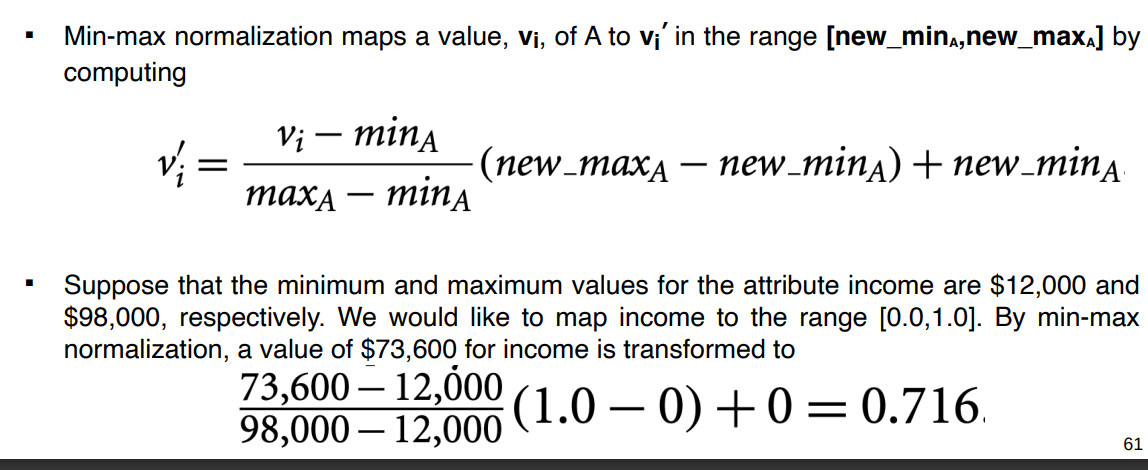

In [10]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# MinMaxScaler always accepts 2D data, so we make a 2D list
data = np.array([[200], [300], [400], [600], [1000]])
scalar = MinMaxScaler(feature_range=(0, 1))
scaled_data = scalar.fit_transform(data)
print (f"Original data {data}")
print (f"Min max normalized data {scaled_data}")

Original data [[ 200]
 [ 300]
 [ 400]
 [ 600]
 [1000]]
Min max normalized data [[0.   ]
 [0.125]
 [0.25 ]
 [0.5  ]
 [1.   ]]


# Z-score normalization
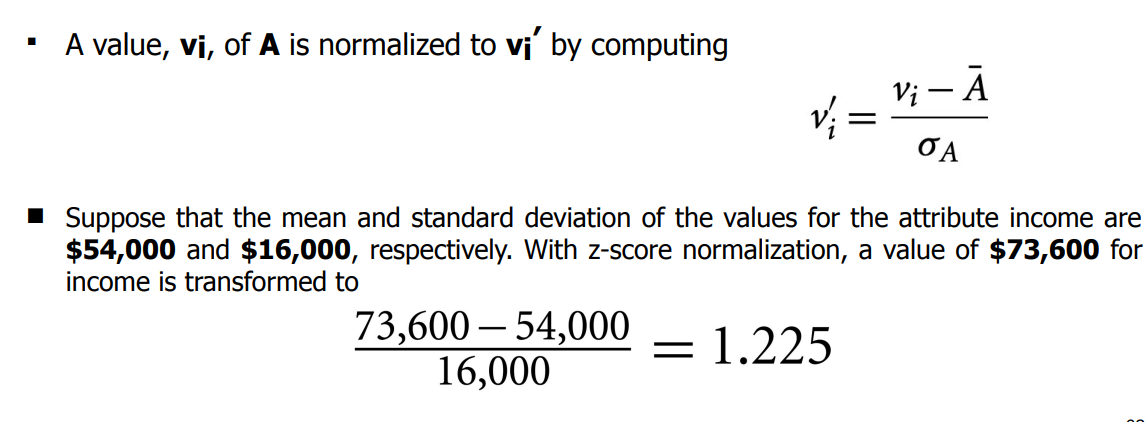

In [11]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# StandardScaler also always accepts 2D data, so we make a 2D list
data = np.array([[200], [300], [400], [600], [1000]])
scalar = StandardScaler()
scaled_data = scalar.fit_transform(data)
print (f"Original data {data}")
print (f"Min max normalized data {scaled_data}")

Original data [[ 200]
 [ 300]
 [ 400]
 [ 600]
 [1000]]
Min max normalized data [[-1.06066017]
 [-0.70710678]
 [-0.35355339]
 [ 0.35355339]
 [ 1.76776695]]


# Decimal Scaling
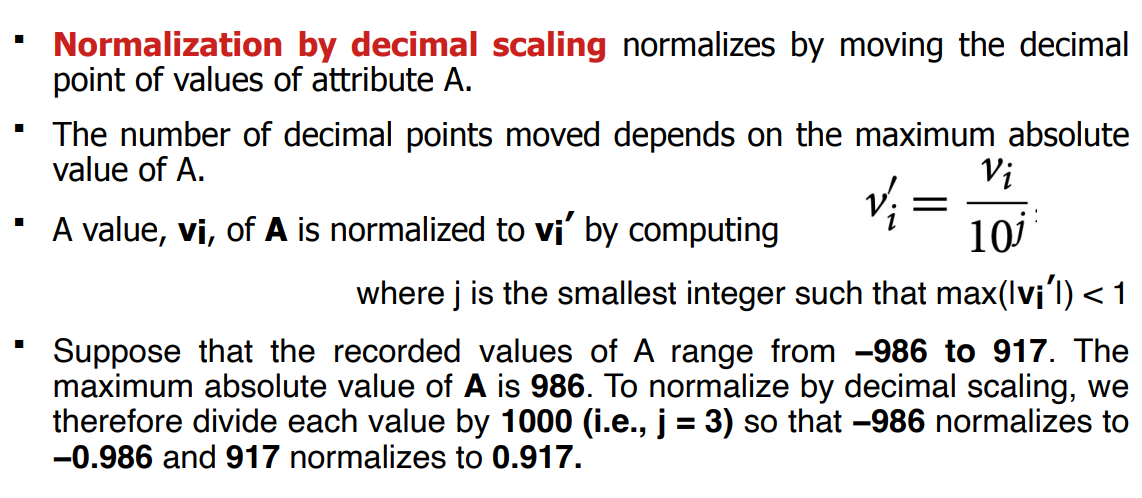

In [13]:
data = np.array([100, 200, 300, 400])

# finding j
max_val = np.max(np.abs(data))
j = len(str(int(max_val)))     #converting the max value to remove any decimals and then converting them to string to find their length using len()
 
# Applying deciaml scaling
scaled_data = data / (10 ** j)

print (f"Original data {data}")
print (f"Min max normalized data {scaled_data}")


Original data [100 200 300 400]
Min max normalized data [0.1 0.2 0.3 0.4]


# Feature Encoding
-> It converts categorical data into a numeric format so that machine learning algorithms can process it.

-> advantage:
- simple and fast
- works for ordinal data

-> disadvantage:
- it gives a random order for nominal data.
- not suitable for tree-based models if nominal

# Label Encoding
-> It assigns each category a unique integer.

In [15]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder will give a number based on alphabetical order
le = LabelEncoder()
cities = ['Ktm', "Dharan", "biratnagar"]
encoded = le.fit_transform(cities)
print(encoded)

[1 0 2]


# One hot encoding
-> It creates binary columns for each category.

- No ordinal assumption
- Works well for nominal data

-> cons:
- increases dimensionality
- may slow down algorithms if many categories.

In [ ]:
import pandas as pd

df = pd.DataFrame({'source' : ['river', 'lake', 'well']})

# this will create new columns with each rows in "source" and tells us if the elements in the above list is present in those rows or not.
df_encoded = pd.get_dummies(df, columns=['source'])
print(df_encoded)

   source_lake  source_river  source_well
0        False          True        False
1         True         False        False
2        False         False         True


# Ordinal encoding
-> It converts categories to integers, preserving their order.

In [21]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories = [['poor', 'fair', 'good']])
quality = [['poor'], ['fair'], ['good']]
encoded = encoder.fit_transform(quality)
print (encoded)

[[0.]
 [1.]
 [2.]]
